In [1]:
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../../../")
from config.label_matchers import matchers

### Load the data:

In [2]:
df = pd.read_csv("./truth_set_ICSME2015.csv")

In [3]:
print("Number of instances:", df.shape[0])

Number of instances: 1390


In [4]:
df.sample(5)

,id,review,class
131,16114,There are also great cleaning ideas and person...,information giving
1367,143200,hope the makers will have a look on it too in ...,information giving
538,17986,Please fix this!,problem discovery
619,18408,Please fix this bug!,problem discovery
37,3799,And it s all available on iPad and iPhone.,information giving


In [5]:
df.rename(columns={"review": "text", "class": "label"}, inplace=True)

In [ ]:
matcher = {v: k for (k, v) in matchers["review_type"].items()}
df["label"] = df["label"].replace(matcher).astype(int)

/tmp/ipykernel_350756/1161218524.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["label"] = df["label"].replace(matcher).astype(int)


### Clean the data:

In [7]:
print("Number of missing texts:", df["text"].isnull().sum())

Number of missing texts: 0


In [8]:
print("Number of missing labels:", df["label"].isnull().sum())

Number of missing labels: 0


In [9]:
print(f"Number of duplicated texts: {df["text"].duplicated().sum()} ({df["text"].duplicated().sum()/df.shape[0]:.2%})")

Number of duplicated texts: 26 (1.87%)


### Analyze distributions:

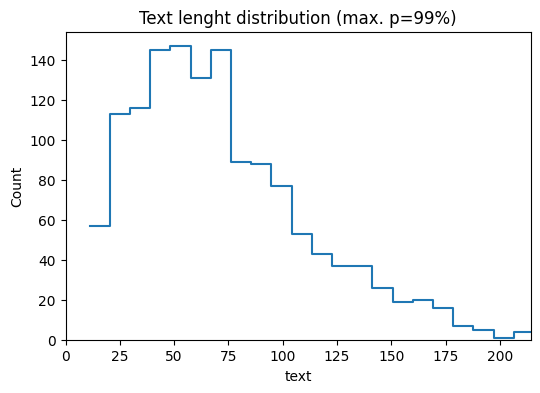

In [10]:
plt.figure(figsize=(6, 4))
sns.histplot(df["text"].str.len(), element="step", fill=False)
plt.xlim([
    0,
    df["text"].str.len().quantile(.99)
])
plt.title("Text lenght distribution (max. p=99%)")
plt.show()

In [11]:
df["label"].value_counts(dropna=False, normalize=True).round(2)

label
1    0.43
3    0.36
2    0.14
0    0.07
Name: proportion, dtype: float64

### Persist datasets:

In [ ]:
df[["id", "text", "label"]].to_parquet("./review_type.parquet", index=False)

In [13]:
print("Number of instances in the persisted dataset:", df.shape[0])

Number of instances in the persisted dataset: 1390
